In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)


In [3]:

def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

def average_eta_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np.abs(np_arrays), axis=0)
    
    return average_array

average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

# average_eta = average_eta_arrays(*list(df['eta_list']))

# average_absolute_eta = [df['eta_list'].tolist()]


# window_size = 5000
# dt = .001
# epsilon = 0.12394270273516043
# N_0_squared = 318.8640217310387


In [4]:
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387
r_m = 0.1
k = 2 * np.pi * 6
m = 2 * np.pi * 3
m_u = 2 * np.pi * 7
dt = 0.001
total_time = 25

k_e_square = k**2 + m**2
k_plus_square = k**2 + (m + m_u)**2

def create_C_matrix(row):
    # Assume that all lists in the row have the same length
    length = len(row['k_e_psi_e_list'])  # The length of the lists in the row
    matrices = []
    
    for i in range(length):
        # Extracting the i-th element from each list in the row
        ke_psi_e = row['k_e_psi_e_list'][i]
        ke_b_e = row['k_e_b_e_list'][i]
        ke_psi_plus = row['k_e_psi_plus_list'][i]
        ke_b_plus = row['k_e_b_plus_list'][i]
        
        heat_flux_psi_e_b_e = row['heat_flux_psi_e_b_e_list'][i]
        heat_flux_psi_e_b_plus = row['heat_flux_psi_e_b_plus_list'][i]
        b_e_psi_plus = row['b_e_psi_plus_list'][i]
        b_e_b_plus = row['b_e_b_plus_list'][i]
        
        psi_plus_b_plus = row['psi_plus_b_plus_list'][i]
        psi_e_psi_plus = row['r_list'][i] 

        # Creating the C matrix for the i-th index
        C_matrix = np.array([
            [ke_psi_e, heat_flux_psi_e_b_e, psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), heat_flux_psi_e_b_plus],
            [heat_flux_psi_e_b_e, ke_b_e, b_e_psi_plus, b_e_b_plus],
            [psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), b_e_psi_plus, ke_psi_plus, psi_plus_b_plus],
            [heat_flux_psi_e_b_plus, b_e_b_plus, psi_plus_b_plus, ke_b_plus]
        ])
        
        matrices.append(C_matrix)

    return matrices  # This returns a list of matrices for the row

In [5]:
df['C_Matrix'] = df.apply(create_C_matrix, axis = 1)
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ...","[[[0.00013793584140409996, 0.06479691188370344..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0...","[[[6.637617490778455e-05, 0.006785805995272157..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],...","[[[1.4299250583653892e-05, -0.0280946723144033..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ...","[[[6.564275531527996e-05, 0.10861145303751879,..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315

In [6]:
C_Mat_Arr = df['C_Matrix']
C_Mat_Arr

0        [[[0.00013793584140409996, 0.06479691188370344...
1        [[[6.637617490778455e-05, 0.006785805995272157...
2        [[[1.4299250583653892e-05, -0.0280946723144033...
3        [[[6.564275531527996e-05, 0.10861145303751879,...
4        [[[4.973479608937477e-07, -0.00506954605892946...
                               ...                        
10709    [[[0.0003056710719046377, -0.0570755958620275,...
10710    [[[1.1021618834990386e-05, 0.00883054898021900...
10711    [[[3.5137087587202417e-05, 0.05941200551124365...
10712    [[[1.085442426508469e-05, -0.02696846172903942...
10713    [[[6.07039887848946e-06, 0.058191941293165794,...
Name: C_Matrix, Length: 10714, dtype: object

In [7]:
average_C_Mat = np.mean(C_Mat_Arr.tolist(), axis = 0)
average_C_Mat

array([[[ 9.39898981e-05, -6.82344367e-03,  1.87794274e-06,
         -1.28853191e-02],
        [-6.82344367e-03,  5.66651146e+01,  2.70094602e-03,
         -4.93601380e+00],
        [ 1.87794274e-06,  2.70094602e-03,  9.70537008e-06,
         -1.32725831e-03],
        [-1.28853191e-02, -4.93601380e+00, -1.32725831e-03,
          1.90495941e+01]],

       [[ 9.37136546e-05, -6.91374314e-03,  1.91326107e-06,
         -1.27231756e-02],
        [-6.91374314e-03,  5.67573860e+01,  2.64596164e-03,
         -4.87414655e+00],
        [ 1.91326107e-06,  2.64596164e-03,  9.70273829e-06,
         -1.37877204e-03],
        [-1.27231756e-02, -4.87414655e+00, -1.37877204e-03,
          1.90064927e+01]],

       [[ 9.29921373e-05, -6.95811210e-03,  1.87605687e-06,
         -1.27049457e-02],
        [-6.95811210e-03,  5.68503202e+01,  2.58977068e-03,
         -4.85255601e+00],
        [ 1.87605687e-06,  2.58977068e-03,  9.70642957e-06,
         -1.41954025e-03],
        [-1.27049457e-02, -4.85255601e+

In [8]:
average_C_Mat.shape

(1000, 4, 4)

In [9]:
average_C_Mat[0]

array([[ 9.39898981e-05, -6.82344367e-03,  1.87794274e-06,
        -1.28853191e-02],
       [-6.82344367e-03,  5.66651146e+01,  2.70094602e-03,
        -4.93601380e+00],
       [ 1.87794274e-06,  2.70094602e-03,  9.70537008e-06,
        -1.32725831e-03],
       [-1.28853191e-02, -4.93601380e+00, -1.32725831e-03,
         1.90495941e+01]])

In [10]:

class Simulation:
    def __init__(self, epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time, U, C, current_time):

        #Make sure this is updated

        self.epsilon = epsilon
        self.N_0_squared = N_0_squared
        self.r_m = r_m
        self.k = k
        self.m = m
        self.m_u = m_u
        self.dt = dt
        self.total_time = total_time
        self.num_steps = int(total_time / dt)
        self.k_e_square = k**2 + m**2
        self.k_plus_square = k**2 + (m + m_u)**2

        self.W_e = np.array([[-1, (k / self.k_e_square)], [-k * N_0_squared, -1]])
        self.W_plus = np.array([[-1, -k / self.k_plus_square], [k * N_0_squared, -1]])
        self.L_e_plus = np.array([[(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), 0],
                                  [0, k / 2]])
        self.L_plus_e = np.array([[(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), 0],
                                  [0, -k / 2]]) 
        self.U = U
        # self.C = np.array([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.C = C

        self.current_time = current_time

        self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]])  
    
        self.Q = np.array([[8/self.k_e_square, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.R = 0
        self.C_History = np.zeros((self.num_steps, 4, 4))              
        # self.C_History = np.zeros(self.num_steps)
        self.U_History = np.zeros(self.num_steps)
        self.R_History = np.zeros(self.num_steps)
        self.C = self.C.astype(np.float64)

    def simulate(self):
        for i in range(self.num_steps):

            self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]]) 
                             
 
            C_dot = (self.A_U @ self.C + self.C @ np.transpose(self.A_U) + self.epsilon * self.Q) 
            U_dot = (self.R - self.r_m * self.U)

            
            self.C += C_dot * self.dt
            self.U += U_dot * self.dt
            self.R = 0.25 * self.k * (self.k_plus_square - self.k_e_square) * self.C[0][2]

            self.C_History[i] = self.C
            self.U_History[i] = self.U
            self.R_History[i] = self.R


In [11]:

def make_plots(sims):

    time_array = np.arange(0, sims[0].total_time, .001)
    fig, axs = plt.subplots(3, 2, figsize = (10, 6))

    # for i in range(10):
    #     axs[i, 0].plot(time_array, sims[i].U_History)
    #     axs[i, 0].set_title(f"U History at {sims[i].current_time}")
    #     axs[i, 0].grid()
    #     axs[i, 1].plot(time_array, sims[i].R_History)
    #     axs[i, 1].set_title(f"R Values at {sims[i].current_time}")
    #     axs[i, 1].grid()
    for i in (0,1,2):
        axs[i, 0].plot(time_array, sims[i+3].U_History, color = 'red')
        axs[i, 0].set_title(f"U History at {sims[i+3].current_time }")
        axs[i, 0].set_xlabel('Time')
        axs[i, 0].set_ylabel('Jet Velocity')
        axs[i, 0].set_ylim(-.5, .5)
        axs[i, 0].grid()

        

        axs[i, 1].plot(time_array, sims[i+3].R_History, color = 'red')
        axs[i, 1].set_title(f"R Values at {sims[i+3].current_time}")
        axs[i, 1].set_xlabel('Time')
        axs[i, 1].set_ylabel('Reynolds Stress')
        axs[i, 1].set_ylim(-3.75, 3.75)
        axs[i, 1].grid()
        if i in (0,1,2):
            axs[i, 0].set_title(f"T=T{(sims[i+3].current_time + 1)//100 - 5}")
            axs[i, 1].set_title(f"T=T{(sims[i+3].current_time + 1)//100 - 5}")
            if i == 1:
                axs[i, 0].set_title(f"T={(sims[i+3].current_time + 1)//100 - 5} (Time of Reversal)")
                axs[i, 1].set_title(f"T={(sims[i+3].current_time + 1)//100 - 5} (Time of Reversal)")
            if i == 2:
                axs[i, 0].set_title(f"T=T+{(sims[i+3].current_time + 1)//100 - 5}")
                axs[i, 1].set_title(f"T=T+{(sims[i+3].current_time + 1)//100 - 5}")


    plt.subplots_adjust(wspace=.4)
    plt.subplots_adjust(hspace=.4)
    plt.tight_layout()
    plt.show()


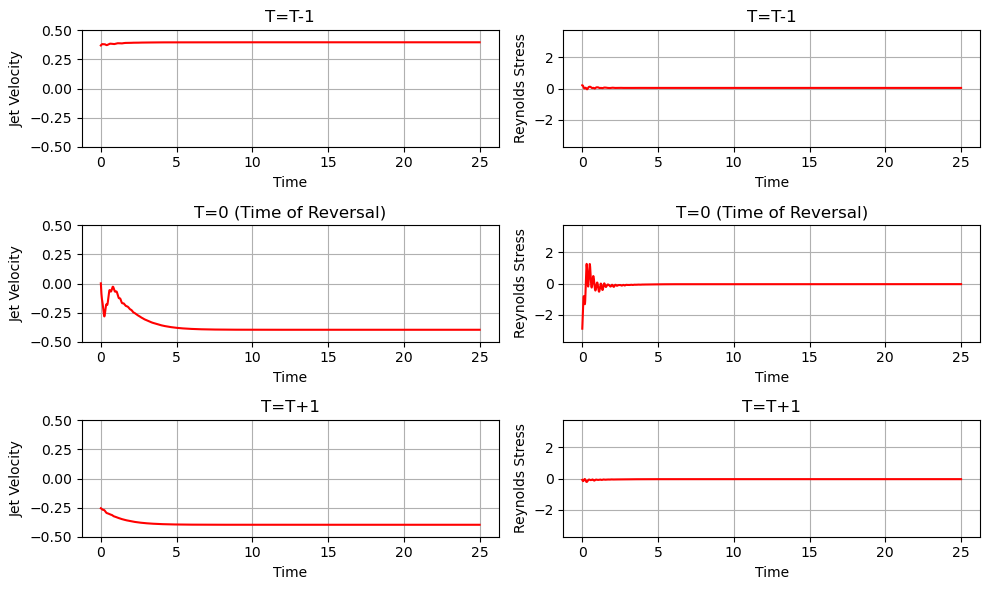

In [12]:


if __name__ == "__main__":
    epsilon = 0.12394270273516043
    N_0_squared = 318.8640217310387
    r_m = 0.1
    k = 2 * np.pi * 6
    m = 2 * np.pi * 3
    m_u = 2 * np.pi * 7
    dt = 0.001
    total_time = 25

    k_e_square = k**2 + m**2

    C_11 = (2*epsilon/k_e_square)*(2-(np.square(k) * N_0_squared/(k_e_square + np.square(k)*N_0_squared)))
    C_12 = -(2*epsilon*k*N_0_squared)/(k_e_square + np.square(k)*N_0_squared)
    C_22 = (2*epsilon*np.square(k)*np.square(N_0_squared))/(k_e_square + np.square(k)*N_0_squared)


#     U_entries = np.array([0.5022827801804544, 0.40950991628144395, 0.36386063053663087, 0.3794275046949516, 0.0021052785076200523, -0.21572820861504546, -0.33933857396878414, -0.44582272206193174, -0.37404536864576843, -0.33003068506849215])
#     C_entries = np.array([[[3.209225737451153e-05,
#   0.004308328634512763,
#   -2.2865617299652913e-06,
#   -0.04298516464145379],
#  [0.004308328634512763,
#   0.5783854780407179,
#   -0.00030696685685982993,
#   -5.770682115715138],
#  [-2.2865617299652913e-06,
#   -0.00030696685685982993,
#   1.6291669619645895e-07,
#   0.003062677432702768],
#  [-0.04298516464145379,
#   -5.770682115715138,
#   0.003062677432702768,
#   57.57539451619873]], [[4.674061556047324e-06,
#   -0.015152332601359049,
#   -5.253684734195421e-06,
#   -0.010543186474467389],
#  [-0.015152332601359049,
#   49.120701665804866,
#   0.017031350041211486,
#   34.17881134504736],
#  [-5.253684734195421e-06,
#   0.017031350041211486,
#   5.905186090373037e-06,
#   0.011850630798608194],
#  [-0.010543186474467389,
#   34.17881134504736,
#   0.011850630798608194,
#   23.782053296147613]], [[4.2902852820799504e-05,
#   -0.05776262630394941,
#   -1.1623135158089199e-05,
#   0.020913647682537603],
#  [-0.05776262630394941,
#   77.76921062722774,
#   0.015648908370296363,
#   -28.15727011871854],
#  [-1.1623135158089199e-05,
#   0.015648908370296363,
#   3.148911133427319e-06,
#   -0.005665873891373166],
#  [0.020913647682537603,
#   -28.15727011871854,
#   -0.005665873891373166,
#   10.194675426741465]], [[0.00014732175533658907,
#   -0.10022658170538411,
#   4.334461987889665e-06,
#   0.003599936287279282],
#  [-0.10022658170538411,
#   68.18658695312973,
#   -0.002948840159999165,
#   -2.4491244189076187],
#  [4.334461987889665e-06,
#   -0.002948840159999165,
#   1.275274020563772e-07,
#   0.00010591637983396548],
#  [0.003599936287279282,
#   -2.4491244189076187,
#   0.00010591637983396548,
#   0.08796760018818137]], [[0.00037464754867079866,
#   -0.43371234047679336,
#   -0.0001046607960770223,
#   -0.07335717575778004],
#  [-0.43371234047679336,
#   502.0889498656411,
#   0.1211610191599468,
#   84.92224892850105],
#  [-0.0001046607960770223,
#   0.1211610191599468,
#   2.9237832395644953e-05,
#   0.02049291511451366],
#  [-0.07335717575778004,
#   84.92224892850105,
#   0.02049291511451366,
#   14.36356718267584]], [[0.000502036223101408,
#   -0.03506758548396667,
#   2.044096583350114e-05,
#   0.04254621386930327],
#  [-0.03506758548396667,
#   2.4494956640348073,
#   -0.001427815929920163,
#   -2.971883149514389],
#  [2.044096583350114e-05,
#   -0.001427815929920163,
#   8.322767660571007e-07,
#   0.001732316641764691],
#  [0.04254621386930327,
#   -2.971883149514389,
#   0.001732316641764691,
#   3.6056767048198615]], [[2.6475415454580633e-05,
#   -0.026549380836582464,
#   3.691906861667028e-06,
#   0.0009266904809122064],
#  [-0.026549380836582464,
#   26.623552858504414,
#   -0.0037022210832439034,
#   -0.9292794115953044],
#  [3.691906861667028e-06,
#   -0.0037022210832439034,
#   5.148238862807293e-07,
#   0.00012922384356878395],
#  [0.0009266904809122064,
#   -0.9292794115953044,
#   0.00012922384356878395,
#   0.03243594983000424]], [[2.3132908740317164e-06,
#   -0.013119841309147893,
#   -3.2784103608848675e-06,
#   0.006064271697738729],
#  [-0.013119841309147893,
#   74.40924870689803,
#   0.018593521534156204,
#   -34.393548698536115],
#  [-3.2784103608848675e-06,
#   0.018593521534156204,
#   4.646183761415681e-06,
#   -0.008594323951331568],
#  [0.006064271697738729,
#   -34.393548698536115,
#   -0.008594323951331568,
#   15.89743496454513]], [[0.00025615893953517414,
#   -0.1361574153724205,
#   -9.749944394245619e-06,
#   -0.03861531552553974],
#  [-0.1361574153724205,
#   72.37241766591642,
#   0.005182435682917152,
#   20.525387735008287],
#  [-9.749944394245619e-06,
#   0.005182435682917152,
#   3.711032527827448e-07,
#   0.0014697795822525405],
#  [-0.03861531552553974,
#   20.525387735008287,
#   0.0014697795822525405,
#   5.821161642232034]], [[0.00010069930425200607,
#   0.10780210165882807,
#   -9.21441099886821e-06,
#   -0.010822046507882056],
#  [0.10780210165882807,
#   115.40589290445659,
#   -0.009864346914853939,
#   -11.585376547187273],
#  [-9.21441099886821e-06,
#   -0.009864346914853939,
#   8.431574645598605e-07,
#   0.0009902628932066844],
#  [-0.010822046507882056,
#   -11.585376547187273,
#   0.0009902628932066844,
#   1.163033761640206]]])

    U_entries = np.array([average_U[99], average_U[199], average_U[299], average_U[399], average_U[499], average_U[599], average_U[699], average_U[799], average_U[899], average_U[999]])
    C_entries = np.array([average_C_Mat[99], average_C_Mat[199], average_C_Mat[299], average_C_Mat[399], average_C_Mat[499], average_C_Mat[599], average_C_Mat[699], average_C_Mat[799], average_C_Mat[899], average_C_Mat[999]])
    
    current_time_entries = np.array([99, 199, 299, 399, 499 ,599, 699, 799, 899, 999])
    sims = [Simulation(epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time, U_entries[i], C_entries[i], current_time_entries[i]) for i in range(10)]
    for i in sims:
        i.simulate()
    make_plots(sims)
    



In [13]:

df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ...","[[[0.00013793584140409996, 0.06479691188370344..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0...","[[[6.637617490778455e-05, 0.006785805995272157..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],...","[[[1.4299250583653892e-05, -0.0280946723144033..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ...","[[[6.564275531527996e-05, 0.10861145303751879,..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315

In [14]:
average_C_Mat.shape

(1000, 4, 4)

In [15]:
average_C_Mat[0]

array([[ 9.39898981e-05, -6.82344367e-03,  1.87794274e-06,
        -1.28853191e-02],
       [-6.82344367e-03,  5.66651146e+01,  2.70094602e-03,
        -4.93601380e+00],
       [ 1.87794274e-06,  2.70094602e-03,  9.70537008e-06,
        -1.32725831e-03],
       [-1.28853191e-02, -4.93601380e+00, -1.32725831e-03,
         1.90495941e+01]])

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.arange(0, sims[0].total_time, .01)

# Define y functions for Jet Velocity (U_History)
y1 = sims[3].U_History    # Starts at x = -1
y2 = sims[4].U_History    # Starts at x = 0
y3 = sims[5].U_History    # Starts at x = 1

y1 = y1[9::10]  # Downsample for better performance
y2 = y2[9::10]  # Downsample for better performance
y3 = y3[9::10]  # Downsample for better performance


In [17]:

# Define y functions for Reynolds Stress (R_History)
r1 = sims[3].R_History
r2 = sims[4].R_History
r3 = sims[5].R_History

r1 = r1[9::10]  # Downsample for better performance
r2 = r2[9::10]  # Downsample for better performance
r3 = r3[9::10]  # Downsample for better performance


In [18]:

# Shift x arrays
x1 = x - 1
x2 = x
x3 = x + 1

# Define the common maximum endpoint
x_max = 8

# Truncate arrays to only include values <= x_max
mask1 = x1 <= x_max
mask2 = x2 <= x_max
mask3 = x3 <= x_max

x1, y1, r1 = x1[mask1], y1[mask1], r1[mask1]
x2, y2, r2 = x2[mask2], y2[mask2], r2[mask2]
x3, y3, r3 = x3[mask3], y3[mask3], r3[mask3]


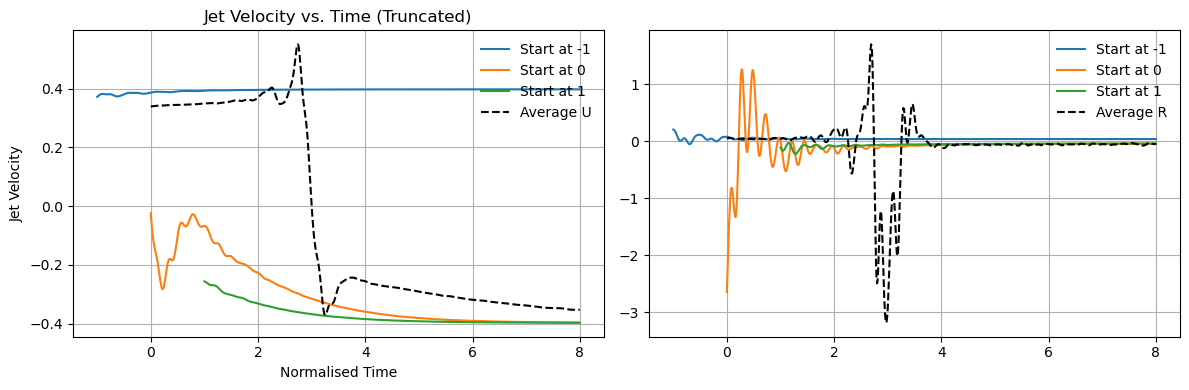

In [19]:

# average_U = average_U[399:]  # Ensure average_U matches the length of x1, x2, x3
# average_R = average_R[399:]  # Ensure average_R matches the length of x1, x2, x3

# average_U = average_U[:len(x1)]  # Ensure average_U matches the length of x1, x2, x3
# average_R = average_R[:len(x1)]  # Ensure average_R matches the length of x1, x2, x3
# ---------------------------------------------------------------
fig, (ax_vel, ax_tau) = plt.subplots(1, 2, figsize=(12, 4))

# ---- Jet Velocity Plot ----
ax_vel.plot(x1, y1, label='Start at -1')
ax_vel.plot(x2, y2, label='Start at 0')
ax_vel.plot(x3, y3, label='Start at 1')
# des_l = len(x1)-300
ax_vel.plot(x2, average_U[199:], label='Average U', linestyle='--', color='black')
# ax_vel.plot(x1, average_U, label='Average U', linestyle='--', color='black')

ax_vel.set_xlabel('Normalised Time')
ax_vel.set_ylabel('Jet Velocity')
ax_vel.set_title('Jet Velocity vs. Time (Truncated)')
ax_vel.legend(frameon=False, loc='upper right')
ax_vel.grid(True)

# ---- Reynolds Stress Plot ----
ax_tau.plot(x1, r1, label='Start at -1')
ax_tau.plot(x2, r2, label='Start at 0')
ax_tau.plot(x3, r3, label='Start at 1')
ax_tau.plot(x2, average_R[199:], label='Average R', linestyle='--', color='black')
# ax_tau.plot(x1, average_R, label='Average R', linestyle='--', color='black')
ax_tau.legend(frameon=False, loc='upper right')
ax_tau.grid(True)

# ---- Shared layout ----
fig.tight_layout()
plt.show()


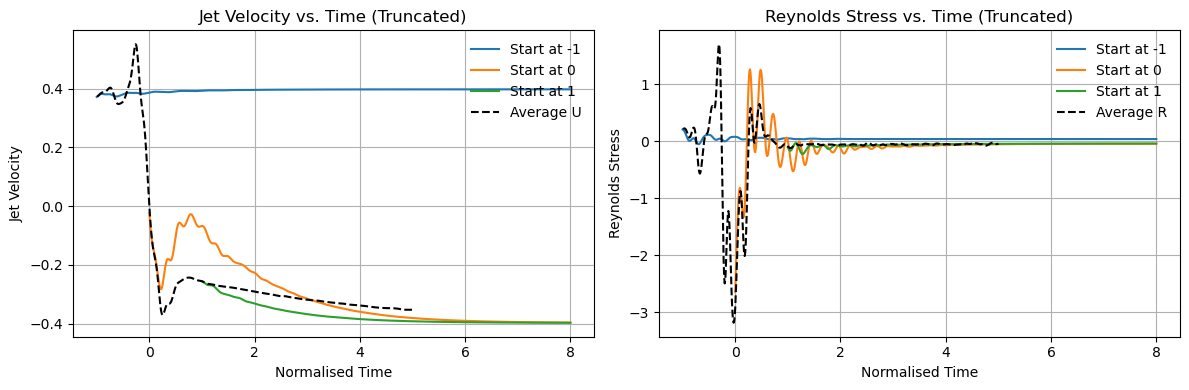

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.arange(0, sims[0].total_time, .01)

# Define y functions for Jet Velocity (U_History)
y1 = sims[3].U_History    # Starts at x = -1
y2 = sims[4].U_History    # Starts at x = 0
y3 = sims[5].U_History    # Starts at x = 1

y1 = y1[9::10]  # Downsample for better performance
y2 = y2[9::10]  # Downsample for better performance
y3 = y3[9::10]  # Downsample for better performance

# Define y functions for Reynolds Stress (R_History)
r1 = sims[3].R_History
r2 = sims[4].R_History
r3 = sims[5].R_History

r1 = r1[9::10]  # Downsample for better performance
r2 = r2[9::10]  # Downsample for better performance
r3 = r3[9::10]  # Downsample for better performance

# Shift x arrays
x1 = x - 1
x2 = x
x3 = x + 1

# Define the common maximum endpoint
x_max = 8
x_min = -1

# Truncate arrays to only include values <= x_max
mask1 = x1 <= x_max
mask2 = x2 <= x_max
mask3 = x3 <= x_max

x1, y1, r1 = x1[mask1], y1[mask1], r1[mask1]
x2, y2, r2 = x2[mask2], y2[mask2], r2[mask2]
x3, y3, r3 = x3[mask3], y3[mask3], r3[mask3]

# ---------------------------------------------------------------
# Prepare black average lines
# ---------------------------------------------------------------

avgU = np.asarray(average_U[199:])
avgR = np.asarray(average_R[199:])

# Make sure average arrays match the available x2 length
n_avg = min(len(x2), len(avgU), len(avgR))

x_avg = x2[:n_avg]
avgU = avgU[:n_avg]
avgR = avgR[:n_avg]

# ---------------------------------------------------------------
# Find where Average U crosses U = 0
# ---------------------------------------------------------------

sign_changes = np.where(np.diff(np.sign(avgU)) != 0)[0]

if len(sign_changes) > 0:
    # Use the first zero crossing
    idx = sign_changes[0]

    # Linear interpolation for a cleaner zero-crossing time
    x_a, x_b = x_avg[idx], x_avg[idx + 1]
    y_a, y_b = avgU[idx], avgU[idx + 1]

    x_zero = x_a - y_a * (x_b - x_a) / (y_b - y_a)
else:
    # Fallback: use the point closest to zero
    idx = np.argmin(np.abs(avgU))
    x_zero = x_avg[idx]

# Shift black curves so Average U crosses zero at x = 0
x_avg_aligned = x_avg - x_zero

# Truncate black curves so nothing appears before x = -1 or after x = 8
mask_avg = (x_avg_aligned >= x_min) & (x_avg_aligned <= x_max)

x_avg_plot = x_avg_aligned[mask_avg]
avgU_plot = avgU[mask_avg]
avgR_plot = avgR[mask_avg]

# ---------------------------------------------------------------
fig, (ax_vel, ax_tau) = plt.subplots(1, 2, figsize=(12, 4))

# ---- Jet Velocity Plot ----
ax_vel.plot(x1, y1, label='Start at -1')
ax_vel.plot(x2, y2, label='Start at 0')
ax_vel.plot(x3, y3, label='Start at 1')

ax_vel.plot(
    x_avg_plot,
    avgU_plot,
    label='Average U',
    linestyle='--',
    color='black'
)

ax_vel.set_xlabel('Normalised Time')
ax_vel.set_ylabel('Jet Velocity')
ax_vel.set_title('Jet Velocity vs. Time (Truncated)')
ax_vel.legend(frameon=False, loc='upper right')
ax_vel.grid(True)

# ---- Reynolds Stress Plot ----
ax_tau.plot(x1, r1, label='Start at -1')
ax_tau.plot(x2, r2, label='Start at 0')
ax_tau.plot(x3, r3, label='Start at 1')

ax_tau.plot(
    x_avg_plot,
    avgR_plot,
    label='Average R',
    linestyle='--',
    color='black'
)

ax_tau.set_xlabel('Normalised Time')
ax_tau.set_ylabel('Reynolds Stress')
ax_tau.set_title('Reynolds Stress vs. Time (Truncated)')
ax_tau.legend(frameon=False, loc='upper right')
ax_tau.grid(True)

# ---- Shared layout ----
fig.tight_layout()
plt.show()